# Loan Default - Data Cleaning & EDA (نسخة معدّلة)

In [95]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 1) تحميل البيانات والفحص الأولي

In [96]:
df = pd.read_csv('Loan_default.csv')
print(df.shape)
df.head()

(255347, 18)


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  str    
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  str    
 11  EmploymentType  255347 non-null  str    
 12  MaritalStatus   255347 non-null  str    
 13  HasMortgage     255347 non-null  str    
 14  HasDependents   255347 non-null  str    
 15  LoanPurpose     255347 non-null  str    
 16  HasCoSigner     255347 non-null  str    
 17  Default         25534

## 2) القيم المفقودة (Missing Values) — على كل الأعمدة، قبل أي تعديل

In [98]:
df.isnull().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

## 3) الصفوف المكررة (Duplicates)

In [99]:
print('Duplicated rows:', df.duplicated().sum())
df = df.drop_duplicates()
print('Shape after dropping duplicates:', df.shape)

Duplicated rows: 0
Shape after dropping duplicates: (255347, 18)


## 4) القيم الفريدة في الأعمدة الفئوية (Categorical Columns)

In [100]:
cat_cols = ['Education', 'EmploymentType', 'MaritalStatus',
            'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']

for col in cat_cols:
    print(col, ':', df[col].unique())

Education : <ArrowStringArray>
['Bachelor's', 'Master's', 'High School', 'PhD']
Length: 4, dtype: str
EmploymentType : <ArrowStringArray>
['Full-time', 'Unemployed', 'Self-employed', 'Part-time']
Length: 4, dtype: str
MaritalStatus : <ArrowStringArray>
['Divorced', 'Married', 'Single']
Length: 3, dtype: str
HasMortgage : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
HasDependents : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
LoanPurpose : <ArrowStringArray>
['Other', 'Auto', 'Business', 'Home', 'Education']
Length: 5, dtype: str
HasCoSigner : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


## 5) وصف إحصائي للأعمدة الرقمية

In [101]:
num_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
            'MonthsEmployed', 'NumCreditLines', 'InterestRate',
            'LoanTerm', 'DTIRatio']

df[num_cols].describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000


## 6) القيم الشاذة (Outliers) — طريقة IQR

In [102]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()
outliers

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
dtype: int64

## 7) توزيع الـ Target (Default) — أهم خطوة كانت ناقصة
لازم تعرفي هل الكلاسين متوازنين ولا فيه Class Imbalance، لأن ده هيأثر على تدريب الموديل بعدين.

Default
0    225694
1     29653
Name: count, dtype: int64
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


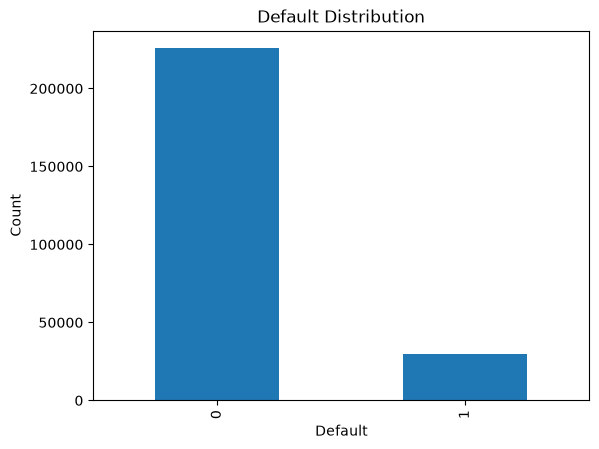

In [103]:
print(df['Default'].value_counts())
print(df['Default'].value_counts(normalize=True) * 100)

df['Default'].value_counts().plot(kind='bar')
plt.title('Default Distribution')
plt.xlabel('Default')
plt.ylabel('Count')
plt.show()

## 8) توزيع الأعمدة الرقمية (Histograms)

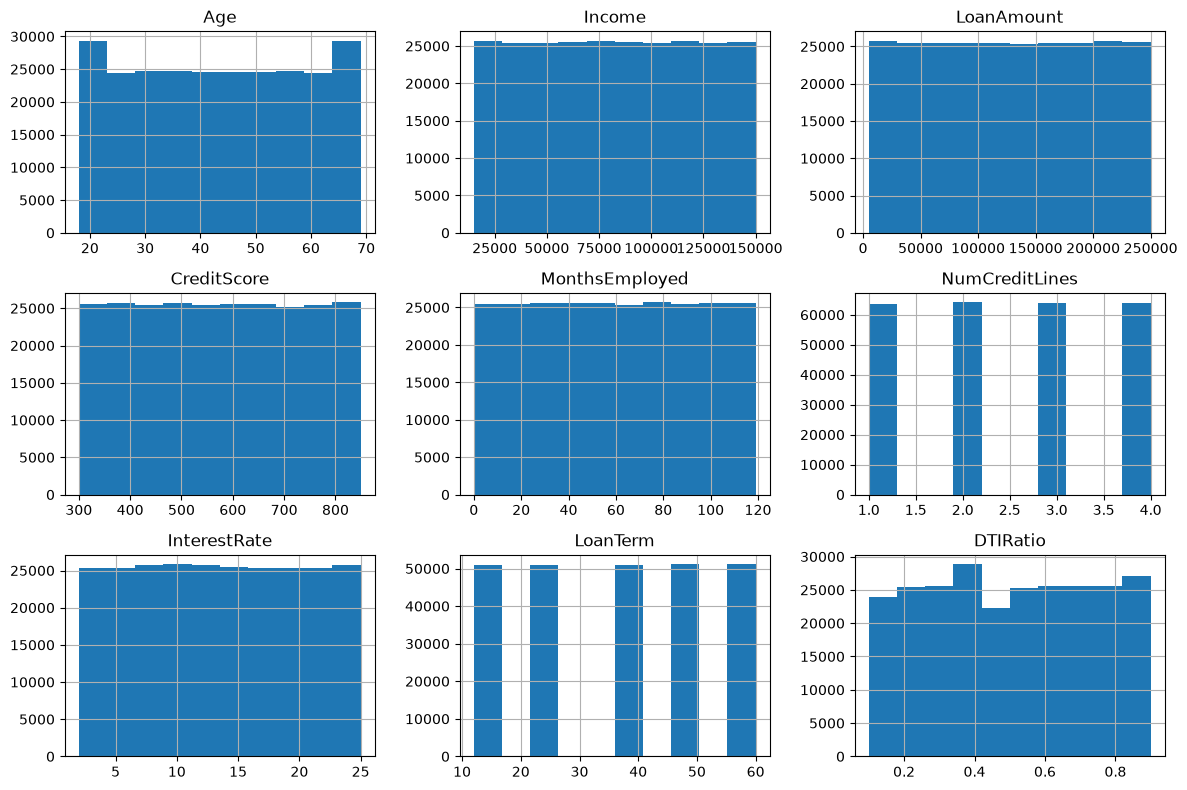

In [104]:
df[num_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

## 9) Boxplots للأعمدة الرقمية

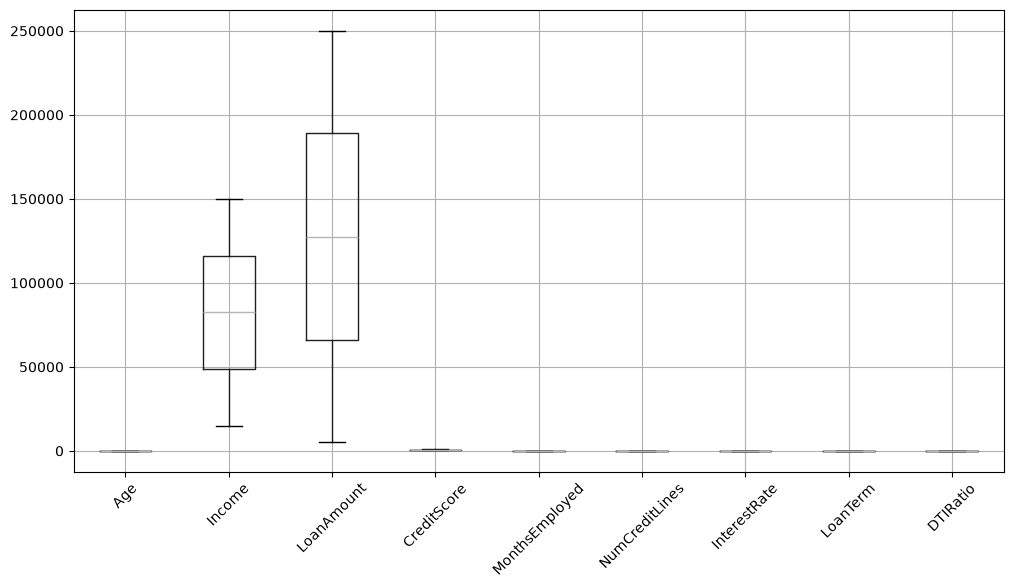

In [105]:
df[num_cols].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

## 10) توزيع الأعمدة الفئوية (loop بدل تكرار نفس الكود 7 مرات)

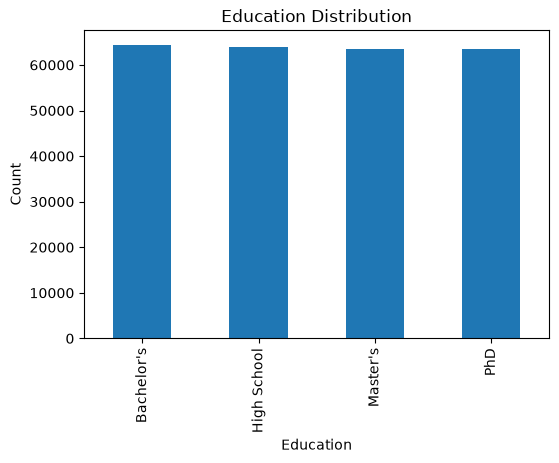

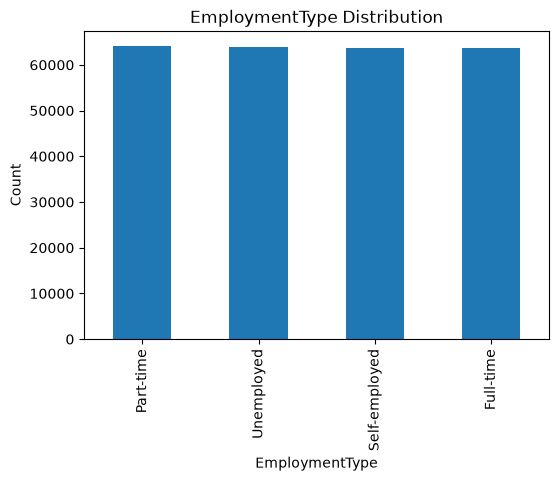

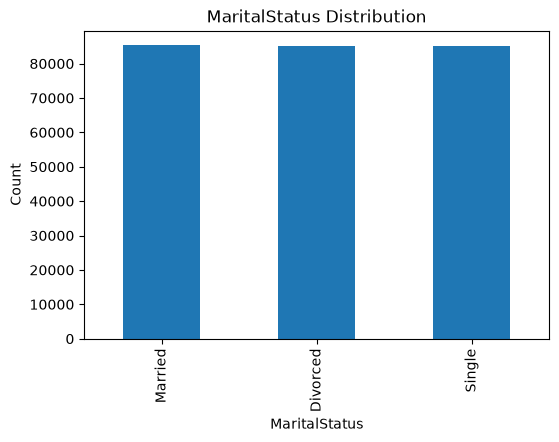

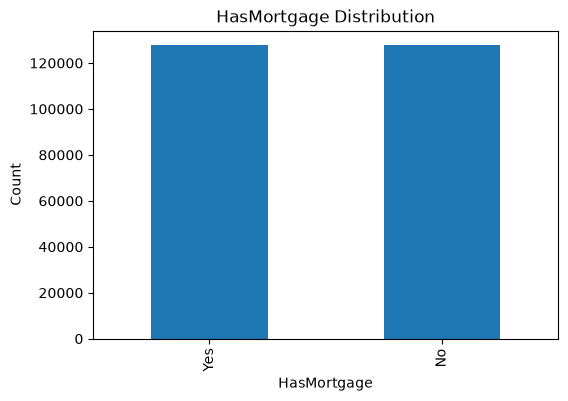

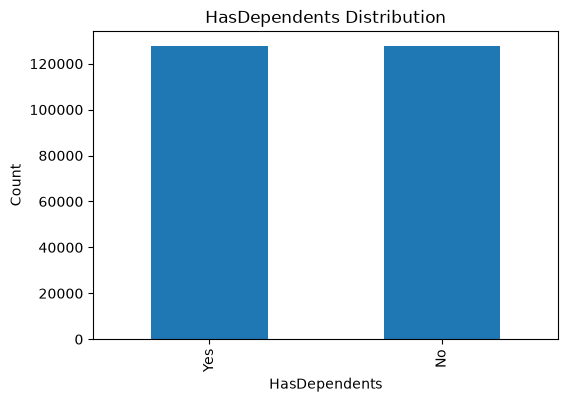

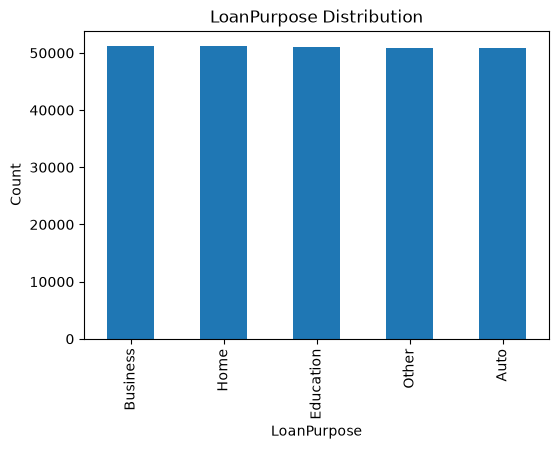

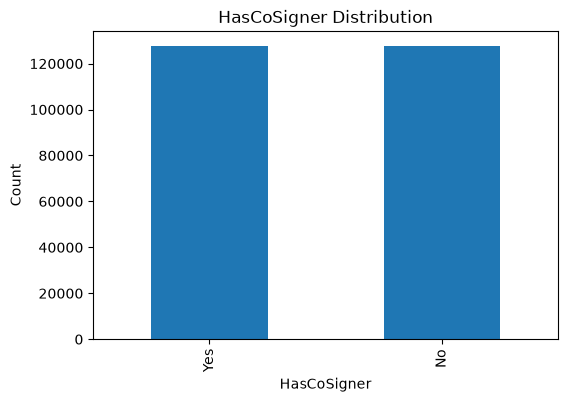

In [106]:
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'{col} Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 11) العلاقة بين الأعمدة الرقمية والـ Target (Bivariate Analysis)
دي كانت ناقصة تمامًا — من غير كدة مش هتعرفي أي Feature فعلاً مؤثر على الـ Default قبل ما تدخلي مرحلة الـ Feature Engineering.

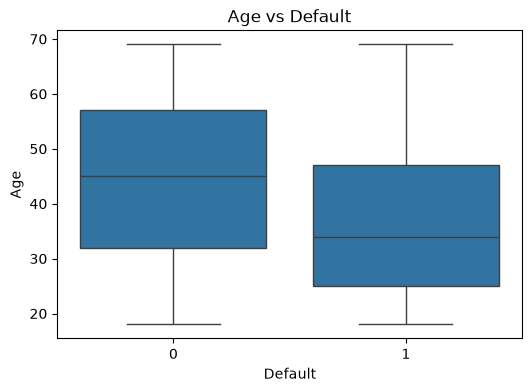

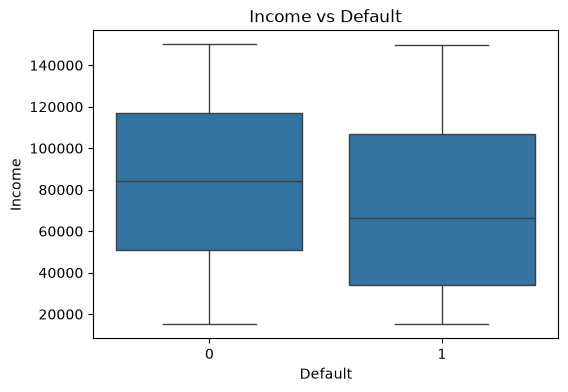

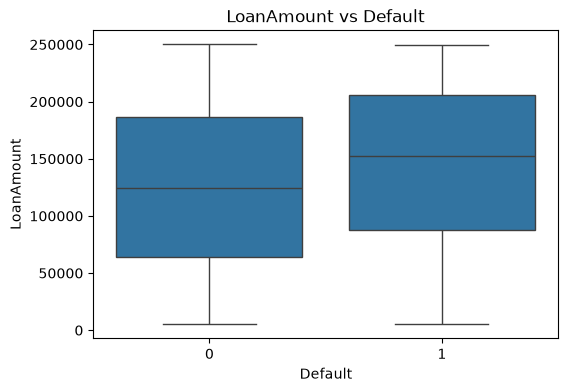

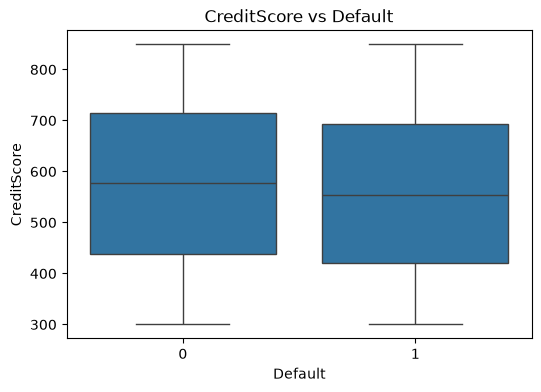

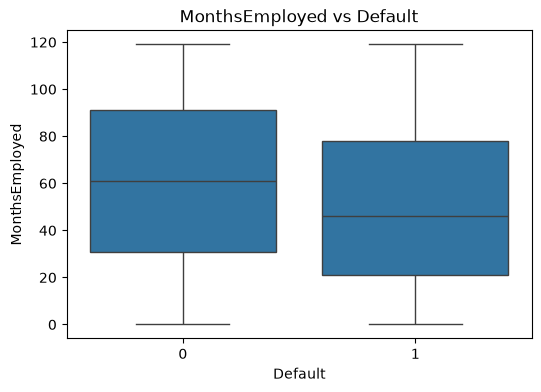

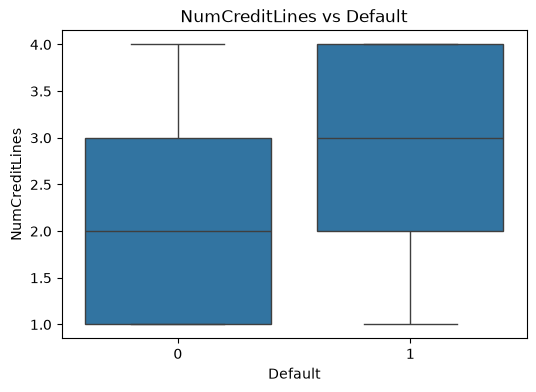

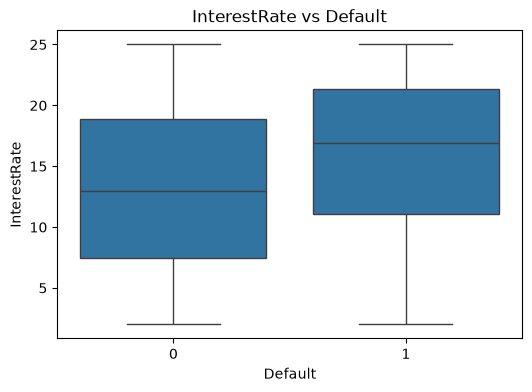

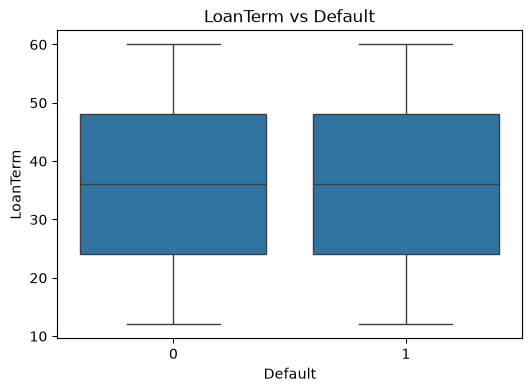

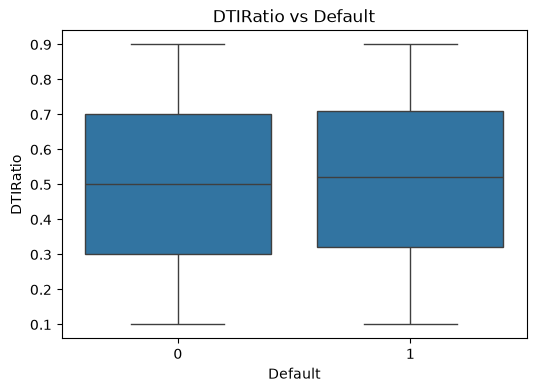

In [107]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Default', y=col, data=df)
    plt.title(f'{col} vs Default')
    plt.show()

## 12) العلاقة بين الأعمدة الفئوية والـ Target

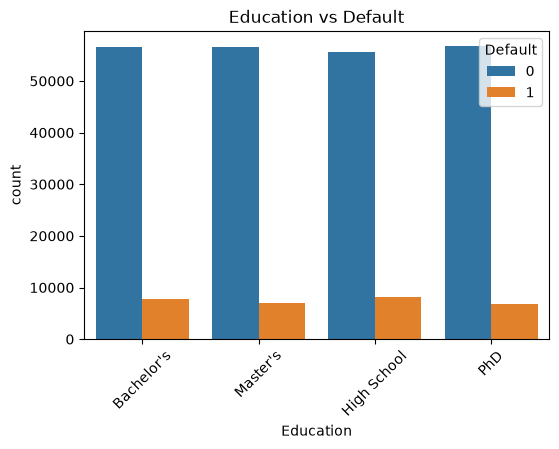

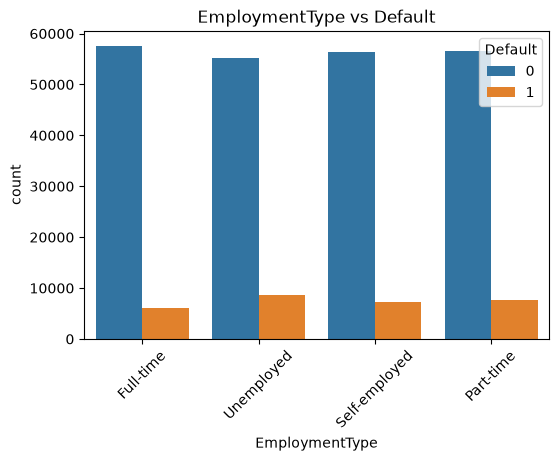

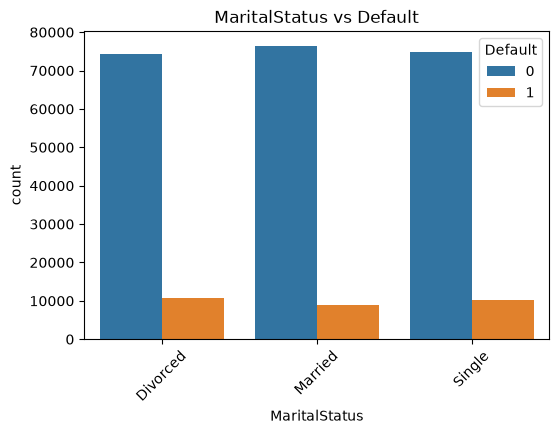

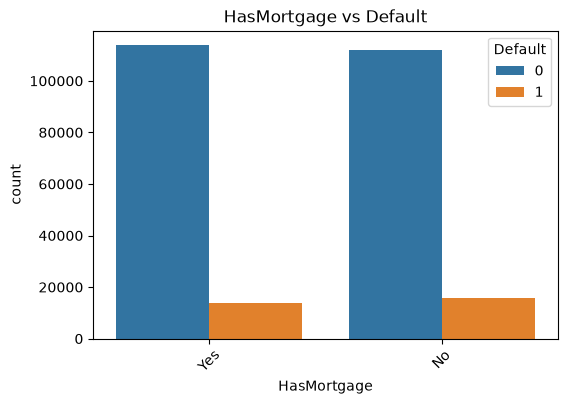

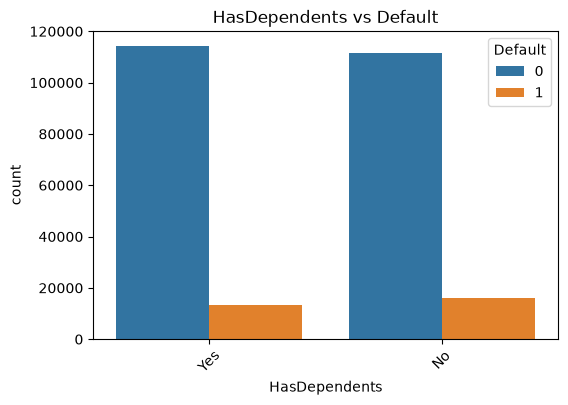

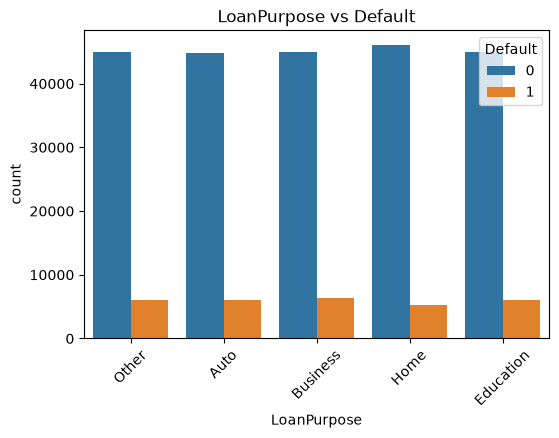

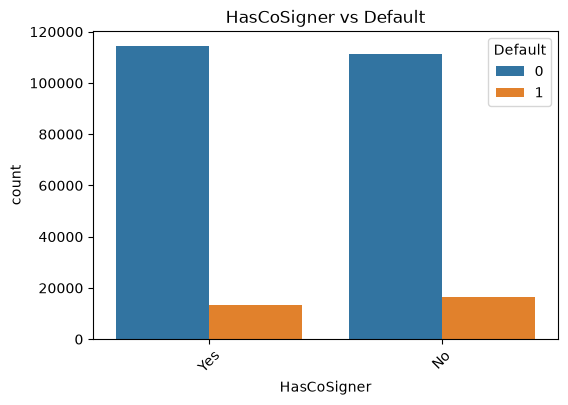

In [108]:
for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='Default', data=df)
    plt.title(f'{col} vs Default')
    plt.xticks(rotation=45)
    plt.show()

## 13) Correlation Heatmap للأعمدة الرقمية فقط

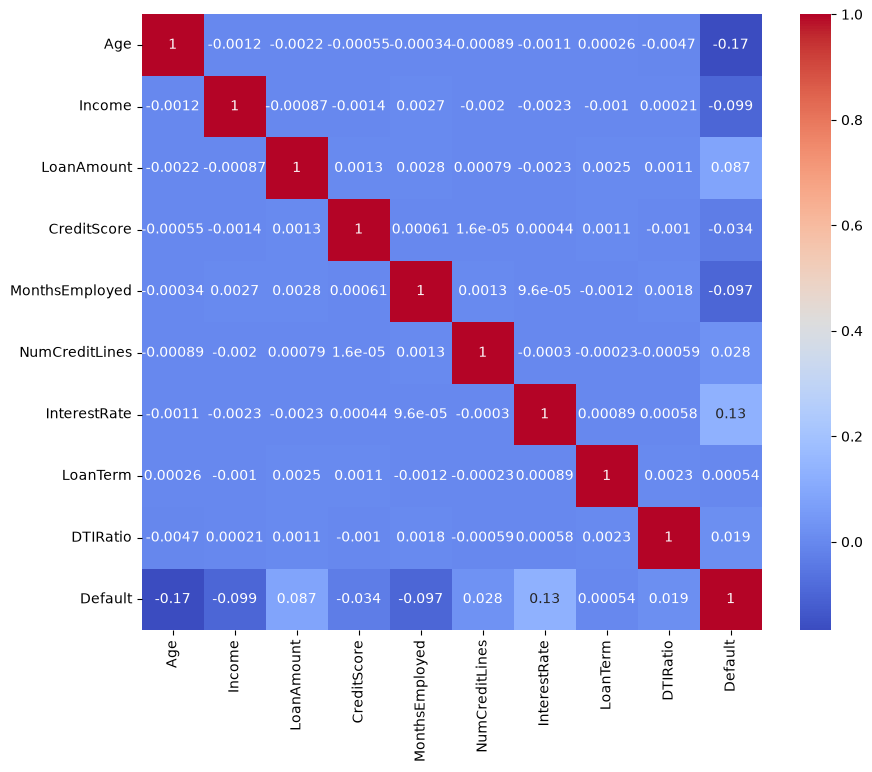

In [109]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols + ['Default']].corr(), annot=True, cmap='coolwarm')
plt.show()

# ---Feaature Engineering---


# Loan-to-Income Ratio
## loan vs income

In [110]:
df['LoanToIncomeRatio'] = df['LoanAmount'] / df['Income']
df['LoanToIncomeRatio'].describe()

count    255347.000000
mean          2.177480
std           2.178357
min           0.033749
25%           0.803628
50%           1.546720
75%           2.671744
max          16.532460
Name: LoanToIncomeRatio, dtype: float64

## Estimated Monthly Payment

In [111]:
df['EstMonthlyPayment'] = df['LoanAmount'] * (df['InterestRate'] / 100) / df['LoanTerm']


df['EstMonthlyPayment'].describe()

count    255347.000000
mean        653.493203
std         739.069765
min           2.077105
25%         174.741083
50%         409.828700
75%         830.177534
max        5180.969733
Name: EstMonthlyPayment, dtype: float64

## Employment Stability


In [112]:
df['EmploymentStability'] = df['MonthsEmployed'] / (df['Age'] * 12)



df['EmploymentStability'].describe()

count    255347.000000
mean          0.131571
std           0.098861
min           0.000000
25%           0.056738
50%           0.114103
75%           0.179012
max           0.550926
Name: EmploymentStability, dtype: float64

### 14.4) Disposable Income


In [113]:
df['DisposableIncome'] = df['Income'] * (1 - df['DTIRatio'])
df['DisposableIncome'].describe()

count    255347.000000
mean      41230.308247
std       28698.244967
min        1509.700000
25%       17824.405000
50%       34053.600000
75%       59109.355000
max      134964.900000
Name: DisposableIncome, dtype: float64

### 14.5) CreditScore Bins


In [114]:
bins = [-float('inf'), 579, 669, 739, float('inf')]
labels = ['Poor', 'Fair', 'Good', 'Excellent']

df['CreditScoreBin'] = pd.cut(df['CreditScore'], bins=bins, labels=labels)
df['CreditScoreBin'].value_counts()

CreditScoreBin
Poor         130223
Excellent     51204
Fair          41847
Good          32073
Name: count, dtype: int64

### 14.6) Risk Flag 


In [115]:
df['RiskFlag'] = (
    (df['HasCoSigner'] == 'No') &
    (df['HasMortgage'] == 'No') &
    (df['DTIRatio'] > 0.5)
).astype(int)

df['RiskFlag'].value_counts()

RiskFlag
0    224057
1     31290
Name: count, dtype: int64

### 14.7) Payment-to-Income Ratio


In [116]:
df['PaymentToIncomeRatio'] = df['EstMonthlyPayment'] / (df['Income'] / 12)
df['PaymentToIncomeRatio'].describe()

count    255347.000000
mean          0.133997
std           0.211647
min           0.000211
25%           0.026643
50%           0.065499
75%           0.151601
max           3.627208
Name: PaymentToIncomeRatio, dtype: float64

### 14.8) Total Debt Burden


In [117]:
df['TotalDebtBurden'] = df['DTIRatio'] + df['LoanToIncomeRatio']
df['TotalDebtBurden'].describe()

count    255347.000000
mean          2.677692
std           2.190704
min           0.148034
25%           1.304530
50%           2.052627
75%           3.192460
max          17.270600
Name: TotalDebtBurden, dtype: float64

### 14.9) Age at Loan Payoff


In [118]:
df['AgeAtPayoff'] = df['Age'] + (df['LoanTerm'] / 12)
df['AgeAtPayoff'].describe()

count    255347.000000
mean         46.500464
std          15.057182
min          19.000000
25%          34.000000
50%          46.000000
75%          59.000000
max          74.000000
Name: AgeAtPayoff, dtype: float64

In [119]:
df['IncomePerCreditLine'] = df['Income'] / (df['NumCreditLines'] + 1)
df['IncomePerCreditLine'].describe()

count    255347.000000
mean      26458.917769
std       16251.214574
min        3000.000000
25%       13925.166667
50%       23567.600000
75%       35009.583333
max       74998.500000
Name: IncomePerCreditLine, dtype: float64

In [120]:
# df['Income_log'] = np.log1p(df['Income'])
# df['LoanAmount_log'] = np.log1p(df['LoanAmount'])

# print('Income skew before:', df['Income'].skew(), '-> after log:', df['Income_log'].skew())
# print('LoanAmount skew before:', df['LoanAmount'].skew(), '-> after log:', df['LoanAmount_log'].skew())

In [121]:
df['HighEducation_FullTime'] = (
    (df['Education'].isin(["Bachelor's", "Master's", "PhD"])) &
    (df['EmploymentType'] == 'Full-time')
).astype(int)

df['HighEducation_FullTime'].value_counts()

HighEducation_FullTime
0    207684
1     47663
Name: count, dtype: int64

In [122]:
new_num_feats = ['LoanToIncomeRatio', 'EstMonthlyPayment', 'EmploymentStability',
                 'DisposableIncome', 'RiskFlag', 'PaymentToIncomeRatio',
                 'TotalDebtBurden', 'AgeAtPayoff', 'IncomePerCreditLine',
                  'HighEducation_FullTime']

df[new_num_feats + ['Default']].corr()['Default'].sort_values(key=abs, ascending=False)

Default                   1.000000
TotalDebtBurden           0.179982
LoanToIncomeRatio         0.178963
PaymentToIncomeRatio      0.167643
AgeAtPayoff              -0.166986
EstMonthlyPayment         0.105747
IncomePerCreditLine      -0.090236
DisposableIncome         -0.079205
HighEducation_FullTime   -0.036173
RiskFlag                  0.031140
EmploymentStability       0.003440
Name: Default, dtype: float64

In [123]:
binary_cols = ['HasMortgage', 'HasDependents', 'HasCoSigner']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

nominal_cols = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose', 'CreditScoreBin']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

df = df.drop(columns=['LoanID'])  #dropping LoanID 

df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,HasMortgage,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,CreditScoreBin_Fair,CreditScoreBin_Good,CreditScoreBin_Excellent
0,56,85994,50587,520,80,4,15.23,36,0.44,1,...,False,False,False,False,False,False,True,False,False,False
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,False,True,False,False,False,False,True,False,False,False
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,True,False,False,False,False,False,False,False,False,False
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,False,True,False,True,False,False,False,False,False,True
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,True,False,False,False,False,False,False,True,False,False


In [174]:
print(df.columns.tolist())

['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Default', 'LoanToIncomeRatio', 'EstMonthlyPayment', 'EmploymentStability', 'DisposableIncome', 'RiskFlag', 'PaymentToIncomeRatio', 'TotalDebtBurden', 'AgeAtPayoff', 'IncomePerCreditLine', 'HighEducation_FullTime', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'CreditScoreBin_Fair', 'CreditScoreBin_Good', 'CreditScoreBin_Excellent']


In [124]:
X = df.drop(columns=['Default'])
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (204277, 37)
X_test: (51070, 37)


Feature Scaling

In [125]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [150]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_resampled, y_train_resampled = rus.fit_resample(
    X_train_scaled,
    y_train
)

print("Before:")
print(y_train.value_counts())

print("\nAfter Undersampling:")
print(y_train_resampled.value_counts())

Before:
Default
0    180555
1     23722
Name: count, dtype: int64

After Undersampling:
Default
0    23722
1    23722
Name: count, dtype: int64


From Scratch Models

Logistic Regression Scratch

In [151]:
class LogisticRegressionScratch:

    def __init__(self, learning_rate=0.001, iterations=1000, class_weight=7):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.class_weight = class_weight

    def sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        sample_weights = np.where(y == 1, self.class_weight, 1)

        for _ in range(self.iterations):

            linear_model = np.dot(X, self.weights) + self.bias
            predictions = self.sigmoid(linear_model)

            errors = (predictions - y) * sample_weights

            dw = np.dot(X.T, errors) / np.sum(sample_weights)
            db = np.sum(errors) / np.sum(sample_weights)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        probabilities = self.sigmoid(linear_model)

        return (probabilities >= 0.7).astype(int)

In [152]:
logistic_model = LogisticRegressionScratch(
    learning_rate=0.001,
    iterations=1000
)

logistic_model.fit(X_train_resampled, y_train_resampled)
y_pred_logistic = logistic_model.predict(X_test_scaled)

In [153]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Logistic Regression From Scratch")
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print(classification_report(y_test, y_pred_logistic))

Logistic Regression From Scratch
Accuracy: 0.8351478363031134
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     45139
           1       0.32      0.36      0.34      5931

    accuracy                           0.84     51070
   macro avg       0.62      0.63      0.62     51070
weighted avg       0.84      0.84      0.84     51070



Bulit In Model

GradientBoosting Model

In [154]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [155]:
gb_model = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42
)
gb_model.fit(X_train_resampled, y_train_resampled)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [156]:
y_probs_gb = gb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_gb = (y_probs_gb >= 0.58).astype(int)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.7719796357940082

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86     45139
           1       0.27      0.57      0.37      5931

    accuracy                           0.77     51070
   macro avg       0.60      0.68      0.61     51070
weighted avg       0.86      0.77      0.80     51070



Gaussian Naive Bayes Model

In [157]:
from sklearn.naive_bayes import GaussianNB

In [158]:
nb_model = GaussianNB()
nb_model.fit(X_train_resampled, y_train_resampled)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[23722.,23722.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.5,0.5]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.73e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,37
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 37)","[[ 0.06, 0.04,-0.03,..., 0. , 0. , 0.01], [-0.46,-0.27, 0.24,...,-0.01,-0.04,-0.06]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 37)","[[0.99,0.99,0.98,...,1. ,1.01,1.01], [0.86,1.1 ,0.96,...,0.99,0.91,0.91]]"


In [159]:
y_probs_nb = nb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_nb = (y_probs_nb >= 0.65).astype(int)
print("nb Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb))

nb Accuracy: 0.8068337575876249

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.86      0.89     45139
           1       0.27      0.38      0.31      5931

    accuracy                           0.81     51070
   macro avg       0.59      0.62      0.60     51070
weighted avg       0.84      0.81      0.82     51070



AdaBoost Model

In [160]:
from sklearn.ensemble import AdaBoostClassifier

In [161]:
ada_model = AdaBoostClassifier(n_estimators=200, learning_rate=0.02, random_state=42)
ada_model.fit(X_train_resampled, y_train_resampled)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",200
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](200,)","[0.39,0.39,0.39,...,0.48,0.45,0.47]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](200,)","[0.01,0.01,0.01,...,0. ,0. ,0. ]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](37,)","[0.34,0. ,0. ,...,0. ,0. ,0. ]"


In [162]:
y_probs_ada = ada_model.predict_proba(X_test_scaled)[:, 1]
y_pred_ada = (y_probs_ada >= 0.55).astype(int)
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("\nClassification Report:\n", classification_report(y_test, y_pred_ada))

AdaBoost Accuracy: 0.763266105345604

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.86     45139
           1       0.25      0.53      0.34      5931

    accuracy                           0.76     51070
   macro avg       0.59      0.66      0.60     51070
weighted avg       0.85      0.76      0.80     51070



XGBoost

In [163]:
from xgboost import XGBClassifier

In [164]:
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05,scale_pos_weight=7.6 ,max_depth=4 , random_state=42)
xgb_model.fit(X_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [165]:
y_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = (y_probs >= 0.58).astype(int)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7733111415703936

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.80      0.86     45139
           1       0.27      0.57      0.37      5931

    accuracy                           0.77     51070
   macro avg       0.60      0.68      0.61     51070
weighted avg       0.86      0.77      0.80     51070



DecisionTree Model

In [166]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=6, class_weight="balanced", random_state=42
)
dt_model.fit(X_train_scaled, y_train)

y_probs_dt = dt_model.predict_proba(X_test_scaled)[:, 1]
y_pred_dt = (y_probs_dt >= 0.58).astype(int)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
Accuracy: 0.7545525748972
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     45139
           1       0.25      0.54      0.34      5931

    accuracy                           0.75     51070
   macro avg       0.59      0.66      0.59     51070
weighted avg       0.85      0.75      0.79     51070



RandomForest Model

In [167]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_scaled, y_train)
y_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = (y_probs >= 0.55).astype(int)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
Accuracy: 0.828549050323086
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     45139
           1       0.31      0.40      0.35      5931

    accuracy                           0.83     51070
   macro avg       0.62      0.64      0.63     51070
weighted avg       0.85      0.83      0.84     51070



knn Model

In [168]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=15, weights="distance")
knn_model.fit(X_train_resampled, y_train_resampled)

y_probs_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
y_pred_knn = (y_probs_knn >= 0.65).astype(int)
print("KNN")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN
Accuracy: 0.8010182102995888
              precision    recall  f1-score   support

           0       0.91      0.86      0.88     45139
           1       0.26      0.38      0.31      5931

    accuracy                           0.80     51070
   macro avg       0.59      0.62      0.60     51070
weighted avg       0.84      0.80      0.82     51070



In [169]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_logistic),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "GradientBoosting": accuracy_score(y_test, y_pred_gb),
    "naive bayes": accuracy_score(y_test, y_pred_nb),
    "AdaBoost": accuracy_score(y_test, y_pred_ada),
    "XGBoost": accuracy_score(y_test, y_pred_xgb)
    
}

for model, accuracy in results.items():
    print(model, ":", accuracy)

Logistic Regression : 0.8351478363031134
Decision Tree : 0.7545525748972
Random Forest : 0.828549050323086
KNN : 0.8010182102995888
GradientBoosting : 0.7719796357940082
naive bayes : 0.8068337575876249
AdaBoost : 0.763266105345604
XGBoost : 0.7733111415703936


In [170]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Accuracy"]
)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy
0,Logistic Regression,0.835148
1,Random Forest,0.828549
2,naive bayes,0.806834
3,KNN,0.801018
4,XGBoost,0.773311
5,GradientBoosting,0.771980
6,AdaBoost,0.763266
7,Decision Tree,0.754553



Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.90      0.91     45139
           1       0.32      0.36      0.34      5931

    accuracy                           0.84     51070
   macro avg       0.62      0.63      0.62     51070
weighted avg       0.84      0.84      0.84     51070


Confusion Matrix:
[[40510  4629]
 [ 3790  2141]]


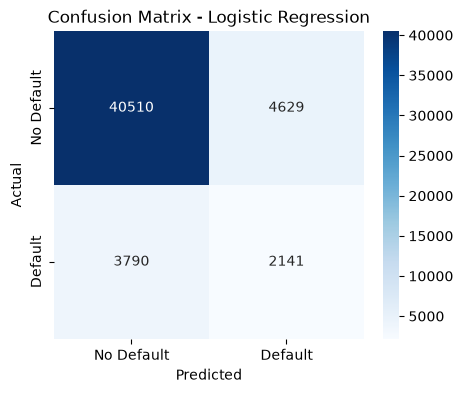


Decision Tree

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.78      0.85     45139
           1       0.25      0.54      0.34      5931

    accuracy                           0.75     51070
   macro avg       0.59      0.66      0.59     51070
weighted avg       0.85      0.75      0.79     51070


Confusion Matrix:
[[35347  9792]
 [ 2743  3188]]


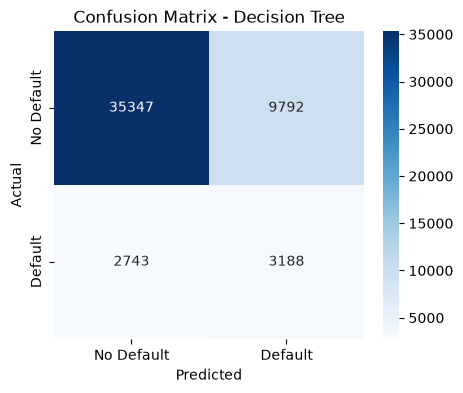


Random Forest

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     45139
           1       0.31      0.40      0.35      5931

    accuracy                           0.83     51070
   macro avg       0.62      0.64      0.63     51070
weighted avg       0.85      0.83      0.84     51070


Confusion Matrix:
[[39923  5216]
 [ 3540  2391]]


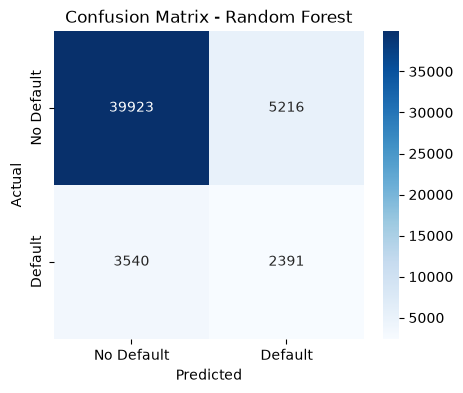


KNN

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88     45139
           1       0.26      0.38      0.31      5931

    accuracy                           0.80     51070
   macro avg       0.59      0.62      0.60     51070
weighted avg       0.84      0.80      0.82     51070


Confusion Matrix:
[[38636  6503]
 [ 3659  2272]]


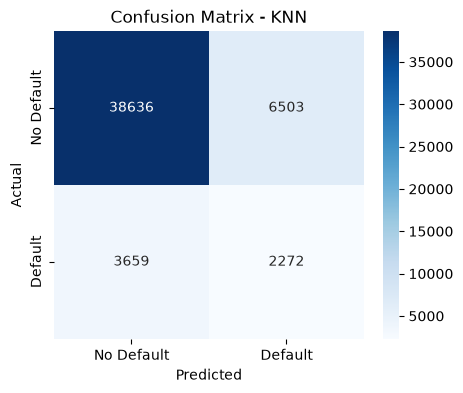


GradientBoosting

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     45139
           1       0.27      0.57      0.37      5931

    accuracy                           0.77     51070
   macro avg       0.60      0.68      0.61     51070
weighted avg       0.86      0.77      0.80     51070


Confusion Matrix:
[[36072  9067]
 [ 2578  3353]]


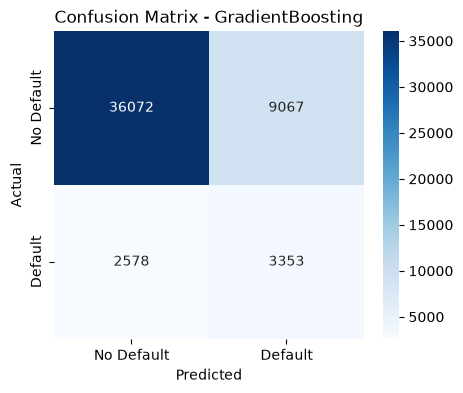


naive bayes

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.86      0.89     45139
           1       0.27      0.38      0.31      5931

    accuracy                           0.81     51070
   macro avg       0.59      0.62      0.60     51070
weighted avg       0.84      0.81      0.82     51070


Confusion Matrix:
[[38969  6170]
 [ 3695  2236]]


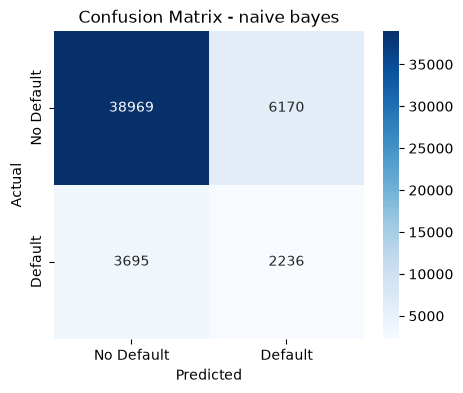


AdaBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.79      0.86     45139
           1       0.25      0.53      0.34      5931

    accuracy                           0.76     51070
   macro avg       0.59      0.66      0.60     51070
weighted avg       0.85      0.76      0.80     51070


Confusion Matrix:
[[35825  9314]
 [ 2776  3155]]


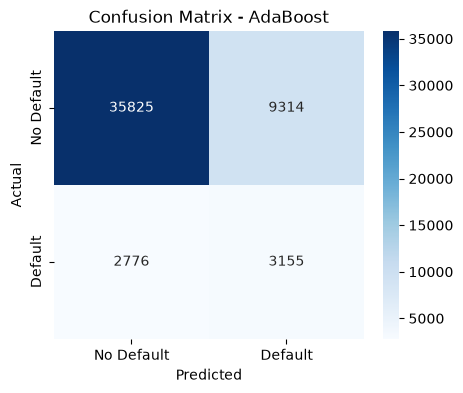


XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.80      0.86     45139
           1       0.27      0.57      0.37      5931

    accuracy                           0.77     51070
   macro avg       0.60      0.68      0.61     51070
weighted avg       0.86      0.77      0.80     51070


Confusion Matrix:
[[36124  9015]
 [ 2562  3369]]


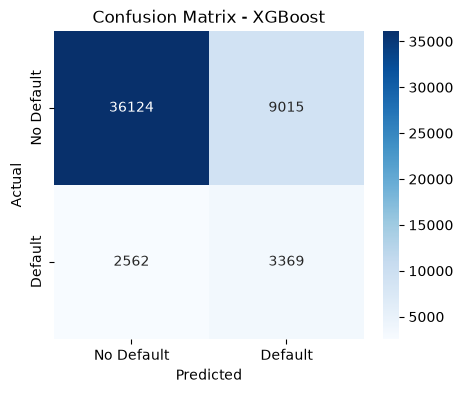

In [171]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

models_predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "KNN": y_pred_knn,
    "GradientBoosting": y_pred_gb,
    "naive bayes": y_pred_nb,
    "AdaBoost": y_pred_ada,
    "XGBoost": y_pred_xgb
}

for name, y_pred in models_predictions.items():

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix:")
    print(cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Default", "Default"],
        yticklabels=["No Default", "Default"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [172]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

print("Target Distribution:")
print(y.value_counts())
print()

print("Target Distribution (%):")
print(y.value_counts(normalize=True) * 100)

Target Distribution:
Default
0    225694
1     29653
Name: count, dtype: int64

Target Distribution (%):
Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64


In [173]:
import joblib

joblib.dump(xgb_model, 'best_model.pkl')
joblib.dump(scaler, 'preprocessor.pkl')

['preprocessor.pkl']